<a href="https://colab.research.google.com/github/velopezriano-cmd/karaoke.2/blob/main/CODIGO_VEGA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HE COPIADO EN MI CODIGO ALGUNAS IDEAS VUESTRAS PARA PROBARLAS CON MIS DATOS Y AL FINAL HE METIDO LAS MIAS, EL ANALISIS DE FIDELIDAD Y EL KARAOKE

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# IMPORTACIONES
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

# Machine Learning
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, roc_curve)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Paleta corporativa al estilo Spotify
SPOTIFY_GREEN  = "#1DB954"
SPOTIFY_BLACK  = "#191414"
SPOTIFY_WHITE  = "#FFFFFF"
SPOTIFY_GRAY   = "#535353"
SPOTIFY_LIGHT  = "#B3B3B3"
ACCENT_COLORS  = ["#1DB954", "#1ED760", "#FF6B6B", "#FFD166", "#06D6A0",
                  "#118AB2", "#EF476F", "#8338EC", "#FB5607", "#3A86FF"]

# Estilo global de matplotlib
plt.rcParams.update({
    "figure.facecolor":  SPOTIFY_BLACK,
    "axes.facecolor":    "#212121",
    "axes.edgecolor":    SPOTIFY_GRAY,
    "axes.labelcolor":   SPOTIFY_WHITE,
    "xtick.color":       SPOTIFY_LIGHT,
    "ytick.color":       SPOTIFY_LIGHT,
    "text.color":        SPOTIFY_WHITE,
    "grid.color":        "#2a2a2a",
    "grid.linestyle":    "--",
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    14,
    "axes.labelsize":    11,
    "legend.facecolor":  "#2a2a2a",
    "legend.edgecolor":  SPOTIFY_GRAY,
})

OUTPUT_DIR = "/mnt/user-data/outputs/"

**LO DE LOS GENEROS POENR LOS NUESTROS**

VER LO DE LOS GÉNEROS

In [ ]:
def cargar_y_limpiar(ruta: str) -> pd.DataFrame:
    """
    Carga el CSV de historial de Spotify y aplica limpieza estándar:
      - Parseo de fechas
      - Creación de la variable objetivo 'skip' basada en razon_fin y tiempo reproducido
      - Síntesis de audio features a partir del género (uso habitual en TFMs
        cuando no se dispone de acceso a la Spotify Web API)
    """
    print("=" * 70)
    print("MÓDULO 0 · CARGA Y LIMPIEZA DE DATOS")
    print("=" * 70)

    df = pd.read_csv(ruta, parse_dates=["fecha_finalizacion"])
    print(f"  ✔ Registros cargados: {len(df):,}")
    print(f"  ✔ Columnas: {df.shape[1]}")
    print(f"  ✔ Valores nulos: {df.isnull().sum().sum()}")

    # --- 0.1 Variable objetivo SKIP ---
    # Un skip real = la canción fue saltada con el botón fwdbtn/backbtn
    # Y el tiempo reproducido fue < 30 segundos (< 50 % de una canción promedio)
    df["skip"] = (
        (df["razon_fin"].isin(["fwdbtn", "backbtn"])) &
        (df["segundos_reproducidos"] < 30)
    ).astype(int)

    print(f"\n  Skip rate: {df['skip'].mean():.2%}  "
          f"({df['skip'].sum():,} skips / {len(df):,} reproducciones)")

    # --- 0.2 Síntesis determinista de audio features por género ---
    # Se asignan valores medios de referencia según el género musical,
    # luego se añade ruido gaussiano acotado para simular variabilidad
    # intra-género. Fuente de referencia: Spotify Audio Features dataset (Kaggle).
    GENRE_PROFILES = {
        # genre              : (dance, energy, valence, tempo, acousticness, speechiness)
        "Indie pop"          : (0.60, 0.55, 0.55, 118, 0.30, 0.06),
        "Pop rock"           : (0.58, 0.72, 0.60, 128, 0.15, 0.05),
        "Rap español"        : (0.78, 0.70, 0.45, 100, 0.10, 0.28),
        "Pop urbano"         : (0.75, 0.68, 0.65, 105, 0.10, 0.15),
        "Pop alternativo"    : (0.55, 0.58, 0.50, 115, 0.25, 0.06),
        "Indie rock"         : (0.52, 0.65, 0.48, 122, 0.20, 0.05),
        "Trap español"       : (0.72, 0.65, 0.38, 95,  0.08, 0.25),
        "Pop punk"           : (0.60, 0.82, 0.62, 138, 0.08, 0.06),
        "Reguetón"           : (0.85, 0.78, 0.72, 100, 0.06, 0.10),
        "Latin trap"         : (0.74, 0.68, 0.42, 98,  0.07, 0.22),
        "Rock alternativo"   : (0.54, 0.75, 0.44, 130, 0.12, 0.05),
        "Pop"                : (0.65, 0.62, 0.68, 120, 0.20, 0.06),
        "Electrónica"        : (0.77, 0.82, 0.50, 128, 0.05, 0.05),
        "Hip-hop"            : (0.75, 0.68, 0.50, 100, 0.10, 0.28),
        "R&B"                : (0.68, 0.55, 0.58, 98,  0.25, 0.10),
        "Pop R&B"            : (0.68, 0.57, 0.60, 102, 0.22, 0.10),
        "Rock"               : (0.52, 0.78, 0.46, 135, 0.10, 0.05),
        "Jazz"               : (0.55, 0.40, 0.62, 120, 0.55, 0.05),
        "Folk"               : (0.45, 0.38, 0.55, 110, 0.70, 0.05),
        "Clásica"            : (0.22, 0.25, 0.42, 95,  0.88, 0.04),
    }
    DEFAULT = (0.55, 0.55, 0.50, 115, 0.20, 0.08)

    np.random.seed(42)
    features = []
    for _, row in df.iterrows():
        genre = row["genero"] if row["genero"] in GENRE_PROFILES else None
        base  = GENRE_PROFILES.get(genre, DEFAULT)
        noise = np.random.normal(0, 0.07, 6)
        vals  = np.clip(np.array(base) + noise, 0, 1)
        # tempo no debe estar en [0,1]; revertimos la escala
        vals[3] = np.clip(base[3] + np.random.normal(0, 8), 60, 200)
        features.append(vals)

    feat_df = pd.DataFrame(features,
                           columns=["danceability", "energy", "valence",
                                    "tempo", "acousticness", "speechiness"])
    df = pd.concat([df.reset_index(drop=True), feat_df], axis=1)

    # --- 0.3 Features temporales adicionales ---
    df["fecha_dt"] = pd.to_datetime(df["fecha_finalizacion"], utc=True)
    df["año_mes"]  = df["fecha_dt"].dt.to_period("M")

    print("\n  Audio features sintéticas añadidas: danceability, energy, valence,")
    print("  tempo, acousticness, speechiness")
    print(f"\n  Dataset final: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print("=" * 70 + "\n")
    return df

In [ ]:
# Cambia la ruta antigua por la del archivo local
ruta = "streaming_history_audio_2025-2026.csv"


In [ ]:
df = cargar_y_limpiar(ruta)

MÓDULO 0 · CARGA Y LIMPIEZA DE DATOS
  ✔ Registros cargados: 24,192
  ✔ Columnas: 22
  ✔ Valores nulos: 52276

  Skip rate: 0.00%  (0 skips / 24,192 reproducciones)

  Audio features sintéticas añadidas: danceability, energy, valence,
  tempo, acousticness, speechiness

  Dataset final: 24,192 filas × 31 columnas



# Recomendador de canciones

### Crear perfil para recomendar canciones

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MÓDULO 1 · SISTEMA DE RECOMENDACIÓN (COSINE SIMILARITY)
# ─────────────────────────────────────────────────────────────────────────────

def construir_perfil_canciones(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construye un perfil único por canción (nombre_cancion_id) promediando
    las audio features de todas sus reproducciones.
    """
    AUDIO_FEATS = ["danceability", "energy", "valence",
                   "tempo", "acousticness", "speechiness"]
    perfil = (df.groupby(["nombre_cancion_id", "nombre_cancion", "nombre_artista"])
                .agg({f: "mean" for f in AUDIO_FEATS})
                .reset_index())
    scaler = MinMaxScaler()
    perfil[AUDIO_FEATS] = scaler.fit_transform(perfil[AUDIO_FEATS])
    return perfil

In [ ]:
construir_perfil_canciones(df)

,nombre_cancion_id,nombre_cancion,nombre_artista,danceability,energy,valence,tempo,acousticness,speechiness
0,spotify:track:01XfZZz4TAYbSDIIWdawzT,"No Pide Tanto, Idiota",Maldita Nerea,0.382344,0.558409,0.532185,0.527307,0.593236,0.547251
1,spotify:track:03tLEN6Sl7O7W4mKgQ1xac,Mood,Facundo Majdalani,0.420094,0.526294,0.350320,0.470306,0.520478,0.590140
2,spotify:track:06VIbrrngDOGagfU2Dow8g,Sin Estrenar,Rosell,0.427310,0.481988,0.465461,0.529246,0.561476,0.515941
3,spotify:track:07MrcfLozSPBfEI8GPOZgc,Como Panas,Bryant Myers,0.500952,0.684560,0.407597,0.456490,0.640040,0.524377
4,spotify:track:08meXSk6aLXfP0EpNA1s0E,Roma,Pole.,0.463846,0.529575,0.415758,0.478042,0.613990,0.488777
...,...,...,...,...,...,...,...,...,...
199,spotify:track:7riXYl8wPi1wkrYrGc56Yh,Todos mis males (feat. Dani Martín) - Acústico,Sidecars,0.452688,0.486794,0.396289,0.574084,0.579011,0.563711
200,spotify:track:7y2B2Ps9TNRUuvzM2SCyHA,Derrapa a 180,Rosell,0.410062,0.543242,0.366434,0.512467,0.634840,0.436923
201,spotify:track:7y7wBlwoftRZQIWcFGv0IY,Jóvenes Eternamente,Pol 3.14,0.468805,0.481968,0.497514,0.470754,0.580070,0.493829
202,spotify:track:7yq4Qj7cqayVTp3FF9CWbm,Riptide,Vance Joy,0.361736,0.541967,0.348728,0.540305,0.522354,0.446978


### Recomendador de canciones según canción mis datos

In [ ]:
def recomendar_canciones(cancion: str, df: pd.DataFrame,
                         perfil: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """
    Recomienda las top_n canciones más similares a 'cancion' usando
    similitud coseno sobre el espacio de audio features normalizadas.

    Parámetros
    ----------
    cancion : str
        Nombre (parcial o completo) de la canción de referencia.
    df      : pd.DataFrame
        Dataset completo.
    perfil  : pd.DataFrame
        Perfil de canciones únicas con audio features.
    top_n   : int
        Número de recomendaciones (por defecto 10).

    Retorna
    -------
    pd.DataFrame con las canciones recomendadas y su score de similitud.
    """
    AUDIO_FEATS = ["danceability", "energy", "valence",
                   "tempo", "acousticness", "speechiness"]

    # Buscar la canción de referencia (búsqueda parcial, case-insensitive)
    mask = perfil["nombre_cancion"].str.contains(cancion, case=False, na=False)
    if mask.sum() == 0:
        print(f"  ⚠ Canción '{cancion}' no encontrada en el historial.")
        return pd.DataFrame()

    idx_ref = perfil[mask].index[0]
    cancion_real = perfil.loc[idx_ref, "nombre_cancion"]
    artista_real = perfil.loc[idx_ref, "nombre_artista"]
    print(f"\n  🎵 Referencia: '{cancion_real}' — {artista_real}")

    # Matriz de features y similitud coseno
    mat  = perfil[AUDIO_FEATS].values
    sims = cosine_similarity(mat[idx_ref].reshape(1, -1), mat)[0]

    perfil_copy = perfil.copy()
    perfil_copy["similitud"] = sims
    recomendadas = (perfil_copy
                    .drop(index=idx_ref)
                    .sort_values("similitud", ascending=False)
                    .head(top_n)
                    [["nombre_cancion", "nombre_artista", "similitud"]]
                    .reset_index(drop=True))

    recomendadas.index += 1
    print(f"\n  Top {top_n} recomendaciones:\n")
    print(recomendadas.to_string())
    return recomendadas

In [ ]:
recomendar_canciones("Mood", df, construir_perfil_canciones(df))

# Le pones una canción de referencia, y te recomienda canciones similares. Quiero mirarlo con cantantes en vez de con artistas


  🎵 Referencia: 'Mood' — Facundo Majdalani

  Top 10 recomendaciones:

      nombre_cancion     nombre_artista  similitud
1   Madrid & Dólares    Claudio Montana   0.996948
2           Lo sabía               Babi   0.996823
3    Llorar al revés             Xavibo   0.996794
4        Como Benito             Xavibo   0.996699
5      Me Encanta(s)               Hens   0.996326
6         Desconfiao               Hens   0.996303
7     Cuenta conmigo               Hens   0.995681
8       Lo Que Tiene              Morad   0.995671
9       Me Va Bonito            Zetazen   0.995263
10   Malibú con Piña  Funzo & Baby Loud   0.995181


,nombre_cancion,nombre_artista,similitud
1,Madrid & Dólares,Claudio Montana,0.996948
2,Lo sabía,Babi,0.996823
3,Llorar al revés,Xavibo,0.996794
4,Como Benito,Xavibo,0.996699
5,Me Encanta(s),Hens,0.996326
6,Desconfiao,Hens,0.996303
7,Cuenta conmigo,Hens,0.995681
8,Lo Que Tiene,Morad,0.995671
9,Me Va Bonito,Zetazen,0.995263
10,Malibú con Piña,Funzo & Baby Loud,0.995181


# Recomendar artistas

### Crear un perfil para recomendar artistas

In [ ]:
def construir_perfil_artistas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construye un perfil único por artista promediando las audio features
    de todas sus canciones.
    """
    AUDIO_FEATS = ["danceability", "energy", "valence",
                   "tempo", "acousticness", "speechiness"]
    # Group by artist and calculate mean of audio features
    perfil_artistas = (df.groupby("nombre_artista")
                         .agg({f: "mean" for f in AUDIO_FEATS})
                         .reset_index())

    # Scale the audio features
    scaler = MinMaxScaler()
    perfil_artistas[AUDIO_FEATS] = scaler.fit_transform(perfil_artistas[AUDIO_FEATS])
    return perfil_artistas

### Crear recomendador de artistas según mis datos

In [ ]:
def recomendar_artistas(artista: str, df: pd.DataFrame,
                        perfil_artistas: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """
    Recomienda los top_n artistas más similares a 'artista' usando
    similitud coseno sobre el espacio de audio features normalizadas.

    Parámetros
    ----------
    artista : str
        Nombre (parcial o completo) del artista de referencia.
    df      : pd.DataFrame
        Dataset completo (no directamente usado para la similitud, pero puede ser útil para contexto).
    perfil_artistas : pd.DataFrame
        Perfil de artistas únicos con audio features.
    top_n   : int
        Número de recomendaciones (por defecto 10).

    Retorna
    -------
    pd.DataFrame con los artistas recomendados y su score de similitud.
    """
    AUDIO_FEATS = ["danceability", "energy", "valence",
                   "tempo", "acousticness", "speechiness"]

    # Buscar el artista de referencia (búsqueda parcial, case-insensitive)
    mask = perfil_artistas["nombre_artista"].str.contains(artista, case=False, na=False)
    if mask.sum() == 0:
        print(f"  ⚠ Artista '{artista}' no encontrado en el historial.")
        return pd.DataFrame()
    elif mask.sum() > 1:
        print(f"  ⚠ Múltiples artistas encontrados para '{artista}'. Usando el primero: {perfil_artistas[mask].iloc[0]['nombre_artista']}")
        idx_ref = perfil_artistas[mask].index[0]
    else:
        idx_ref = perfil_artistas[mask].index[0]

    artista_real = perfil_artistas.loc[idx_ref, "nombre_artista"]
    print(f"\n  🎤 Referencia: '{artista_real}'")

    # Matriz de features y similitud coseno
    mat  = perfil_artistas[AUDIO_FEATS].values
    sims = cosine_similarity(mat[idx_ref].reshape(1, -1), mat)[0]

    perfil_copy = perfil_artistas.copy()
    perfil_copy["similitud"] = sims
    recomendados = (perfil_copy
                    .drop(index=idx_ref) # Excluir el propio artista de referencia
                    .sort_values("similitud", ascending=False)
                    .head(top_n)
                    [["nombre_artista", "similitud"]]
                    .reset_index(drop=True))

    recomendados.index += 1
    print(f"\n  Top {top_n} artistas recomendados:\n")
    print(recomendados.to_string())
    return recomendados

In [ ]:
recomendar_artistas("Rels B", df, construir_perfil_artistas(df))
# No salen cosas con sentido (AJAJJAJAJAJA ONE DIRECTION), ver cuando tengamos todos los datos



  🎤 Referencia: 'Rels B'

  Top 10 artistas recomendados:

    nombre_artista  similitud
1          Quevedo   0.999974
2        Bad Bunny   0.999950
3      Ocer y Rade   0.999941
4   Rauw Alejandro   0.999931
5             Cano   0.999928
6          Melendi   0.999921
7            Pole.   0.999917
8           Xavibo   0.999914
9             Hens   0.999907
10    Bryant Myers   0.999900


,nombre_artista,similitud
1,Quevedo,0.999974
2,Bad Bunny,0.999950
3,Ocer y Rade,0.999941
4,Rauw Alejandro,0.999931
5,Cano,0.999928
6,Melendi,0.999921
7,Pole.,0.999917
8,Xavibo,0.999914
9,Hens,0.999907
10,Bryant Myers,0.999900


# Gráficos para ver las canciones recomendadas

In [ ]:
def plot_recomendaciones(recomendadas: pd.DataFrame, cancion_ref: str):
    """Visualiza las recomendaciones como barras horizontales."""
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle(f"Recomendaciones para: {cancion_ref}",
                 fontsize=15, color=SPOTIFY_GREEN, fontweight="bold")

    labels = [f"{r['nombre_cancion']} — {r['nombre_artista']}"
              for _, r in recomendadas.iterrows()]
    values = recomendadas["similitud"].values

    bars = ax.barh(labels[::-1], values[::-1], color=ACCENT_COLORS[:len(labels)],
                   edgecolor="none", height=0.6)
    ax.set_xlabel("Similitud coseno", color=SPOTIFY_LIGHT)
    ax.set_xlim(0.8, 1.01)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", alpha=0.3)

    for bar, val in zip(bars, values[::-1]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8, color=SPOTIFY_WHITE)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + "modulo1_recomendaciones.png",
                dpi=150, bbox_inches="tight", facecolor=SPOTIFY_BLACK)
    plt.show() # Display the plot
    # plt.close() # Removed this line so the plot is shown
    print("\n  ✔ Gráfico guardado: modulo1_recomendaciones.png")


  🎵 Referencia: 'Mood' — Facundo Majdalani

  Top 10 recomendaciones:

      nombre_cancion     nombre_artista  similitud
1   Madrid & Dólares    Claudio Montana   0.996948
2           Lo sabía               Babi   0.996823
3    Llorar al revés             Xavibo   0.996794
4        Como Benito             Xavibo   0.996699
5      Me Encanta(s)               Hens   0.996326
6         Desconfiao               Hens   0.996303
7     Cuenta conmigo               Hens   0.995681
8       Lo Que Tiene              Morad   0.995671
9       Me Va Bonito            Zetazen   0.995263
10   Malibú con Piña  Funzo & Baby Loud   0.995181


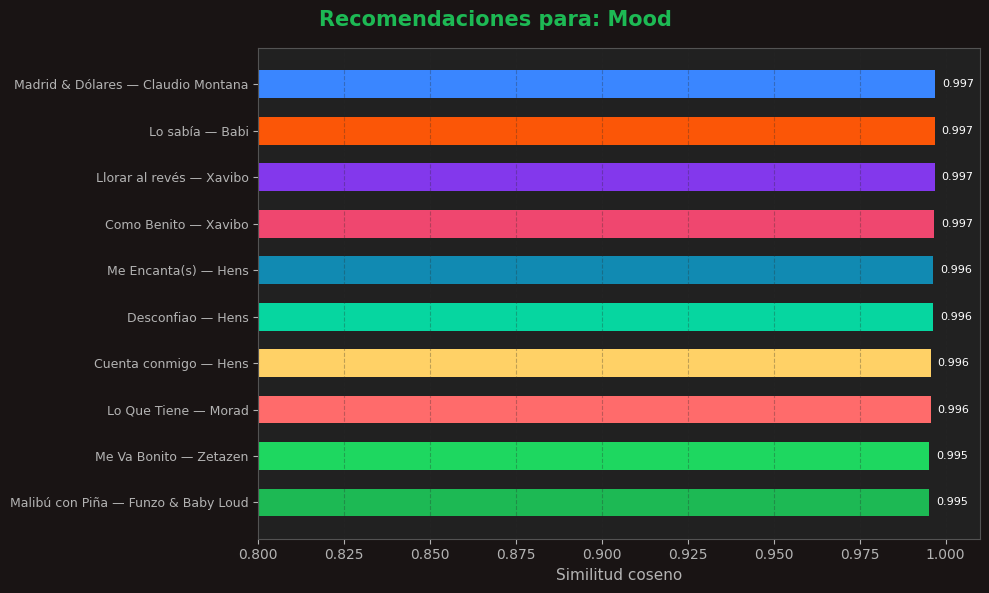


  ✔ Gráfico guardado: modulo1_recomendaciones.png


In [ ]:
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

recomendadas_df = recomendar_canciones("Mood", df, construir_perfil_canciones(df))
if not recomendadas_df.empty:
    plot_recomendaciones(recomendadas_df, "Mood")
else:
    print("No se encontraron recomendaciones para la canción especificada. No se generó el gráfico.")

No me gusta mucho el histograma, voy a ver otro tipo de gráficos

In [ ]:
def plot_recomendaciones_lollipop(recomendadas: pd.DataFrame, cancion_ref: str):
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle(f"Recomendaciones para: {cancion_ref}",
                 fontsize=15, color=SPOTIFY_GREEN, fontweight="bold")

    labels = [f"{r['nombre_cancion']} — {r['nombre_artista']}"
              for _, r in recomendadas.iterrows()]
    values = recomendadas["similitud"].values

    y = np.arange(len(labels))[::-1]

    ax.hlines(y, 0.8, values[::-1], color=SPOTIFY_LIGHT, alpha=0.4)
    ax.scatter(values[::-1], y, color=ACCENT_COLORS[:len(labels)], s=80)

    ax.set_yticks(y)
    ax.set_yticklabels(labels[::-1])
    ax.set_xlim(0.8, 1.01)

    ax.set_xlabel("Similitud coseno", color=SPOTIFY_LIGHT)
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

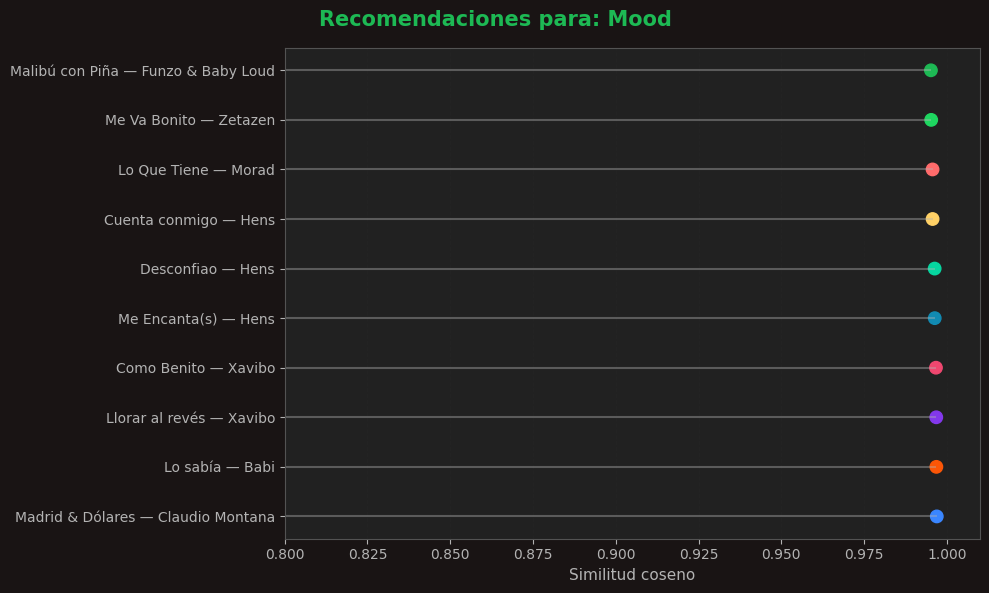

In [ ]:
plot_recomendaciones_lollipop(recomendadas_df, 'Mood')

otra forma!!

In [ ]:
def plot_recomendaciones_ranking(recomendadas: pd.DataFrame, cancion_ref: str):
    fig, ax = plt.subplots(figsize=(10, 6))

    fig.suptitle(f"Top recomendaciones para: {cancion_ref}",
                 fontsize=15, color=SPOTIFY_GREEN, fontweight="bold")

    labels = [f"{r['nombre_cancion']} — {r['nombre_artista']}"
              for _, r in recomendadas.iterrows()]

    ranks = list(range(1, len(labels) + 1))

    bars = ax.bar(ranks, [1]*len(ranks),
                  color=ACCENT_COLORS[:len(ranks)],
                  width=0.6)

    ax.set_xticks(ranks)
    ax.set_xticklabels([f"Top {r}" for r in ranks])

    ax.set_yticks([])
    ax.set_xlabel("Ranking de recomendación")

    for bar, label in zip(bars, labels):
        ax.text(bar.get_x() + bar.get_width()/2,
                0.5,
                label,
                ha="center",
                va="center",
                rotation=90,
                fontsize=9,
                color="white")

    ax.set_ylim(0, 1.2)
    ax.grid(False)

    plt.tight_layout()

    # Mostrar gráfico
    plt.show()

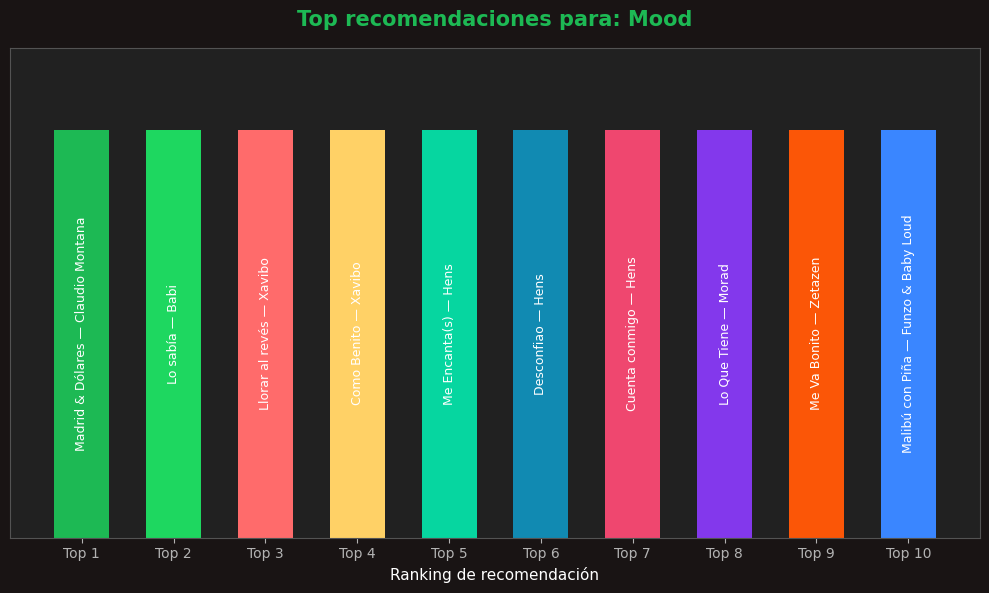

In [ ]:
plot_recomendaciones_ranking(recomendadas_df, 'Mood')

Es que coge la similaridad para la longitud de las figuras!!!!

Voy a hacerlo de alguna otra forma:

In [ ]:
recomendadas = recomendadas_df.sort_values("similitud", ascending=False).reset_index(drop=True)
top = recomendadas.head(5)
print(top[["nombre_cancion", "nombre_artista", "similitud"]])

     nombre_cancion   nombre_artista  similitud
0  Madrid & Dólares  Claudio Montana   0.996948
1          Lo sabía             Babi   0.996823
2   Llorar al revés           Xavibo   0.996794
3       Como Benito           Xavibo   0.996699
4     Me Encanta(s)             Hens   0.996326


In [ ]:
def plot_recomendaciones_podio(recomendadas: pd.DataFrame, cancion_ref: str):

    top = recomendadas.sort_values("similitud", ascending=False).head(5)

    labels = [f"{r['nombre_cancion']}\n{r['nombre_artista']}"
              for _, r in top.iterrows()]

    ranks = ["1º", "2º", "3º", "4º", "5º"]

    # alturas artificiales solo para visualización
    heights = [5,4,3,2,1]

    fig, ax = plt.subplots(figsize=(10,6))

    bars = ax.bar(ranks, heights,
                  color=ACCENT_COLORS[:5],
                  width=0.6)

    fig.suptitle(f"Top recomendaciones para: {cancion_ref}",
                 fontsize=15,
                 fontweight="bold")

    for bar, label in zip(bars, labels):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height()/2,
                label,
                ha="center",
                va="center",
                fontsize=9,
                color="white")

    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_xlabel("Ranking de similitud")

    plt.tight_layout()
    plt.show()

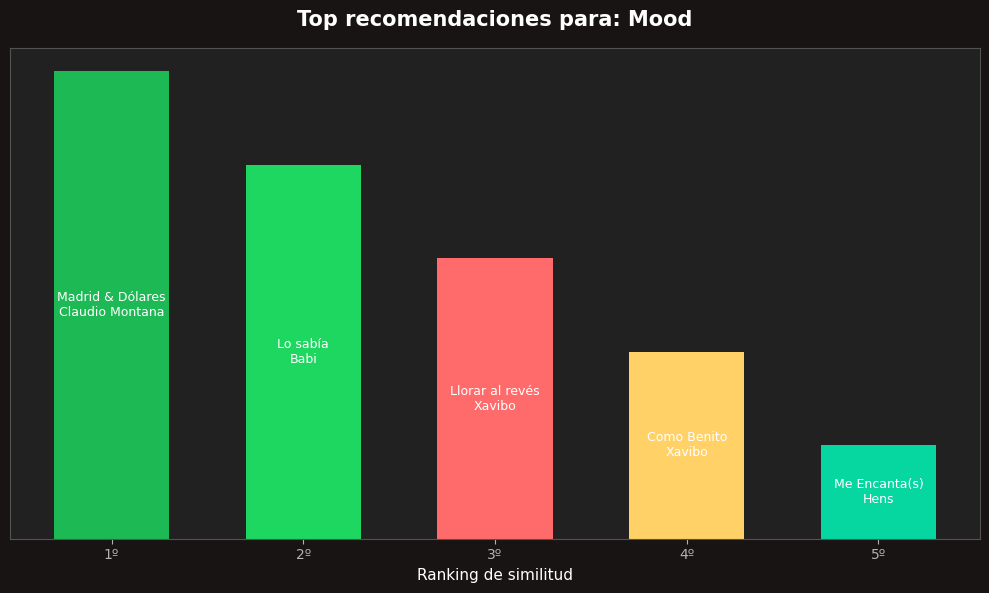

In [ ]:
plot_recomendaciones_podio(recomendadas_df, 'Mood')
# Que haga un podio sin coger ningún valor.

# Predecir si va a pasar una canción

In [ ]:
def modelo_prediccion_skip(df: pd.DataFrame):
    """
    Entrena y evalúa tres clasificadores para predecir si una canción
    será saltada (skip=1):
      - Logistic Regression
      - Random Forest
      - Gradient Boosting

    Features usadas:
      - Audio features: danceability, energy, valence, tempo, acousticness, speechiness
      - Contexto: hora, dia_semana, fin_de_semana, reproduccion_aleatoria,
                  reproduccion_offline, periodo_dia (encoded)
    """
    print("=" * 70)
    print("MÓDULO 2 · PREDICCIÓN DE SKIP")
    print("=" * 70)

    AUDIO_FEATS   = ["danceability", "energy", "valence",
                     "tempo", "acousticness", "speechiness"]
    CONTEXT_FEATS = ["hora", "dia_semana", "fin_de_semana",
                     "reproduccion_aleatoria", "reproduccion_offline"]

    df2 = df.copy()
    # Codificación de periodo_dia
    le = LabelEncoder()
    df2["periodo_dia_enc"] = le.fit_transform(df2["periodo_dia"])

    FEATURES = AUDIO_FEATS + CONTEXT_FEATS + ["periodo_dia_enc"]
    df2["reproduccion_aleatoria"] = df2["reproduccion_aleatoria"].astype(int)
    df2["reproduccion_offline"]   = df2["reproduccion_offline"].astype(int)

    X = df2[FEATURES]
    y = df2["skip"]

    print(f"\n  Distribución skip: {y.value_counts().to_dict()}")
    print(f"  Skip rate: {y.mean():.2%}")
    print(f"  Features utilizadas ({len(FEATURES)}): {FEATURES}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    modelos = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42,
                                                   class_weight="balanced"),
        "Random Forest"      : RandomForestClassifier(n_estimators=200, random_state=42,
                                                       class_weight="balanced", n_jobs=-1),
        "Gradient Boosting"  : GradientBoostingClassifier(n_estimators=200,
                                                            learning_rate=0.05,
                                                            max_depth=4, random_state=42),
    }

    resultados = {}
    trained    = {}

    for nombre, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        y_pred  = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        auc  = roc_auc_score(y_test, y_proba)

        resultados[nombre] = {"Accuracy": acc, "Precision": prec,
                              "Recall": rec, "ROC-AUC": auc}
        trained[nombre]    = (modelo, y_pred, y_proba)

        print(f"\n  ── {nombre} ──")
        print(f"     Accuracy : {acc:.4f}")
        print(f"     Precision: {prec:.4f}")
        print(f"     Recall   : {rec:.4f}")
        print(f"     ROC-AUC  : {auc:.4f}")

    # ── Visualización ──────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle("Módulo 2 · Predicción de Skip", fontsize=17,
                 color=SPOTIFY_GREEN, fontweight="bold", y=0.98)

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # Panel 1 — Métricas comparativas
    ax1 = fig.add_subplot(gs[0, :])
    metrics_df = pd.DataFrame(resultados).T
    x = np.arange(len(metrics_df))
    width = 0.2
    for i, col in enumerate(metrics_df.columns):
        bars = ax1.bar(x + i * width, metrics_df[col], width,
                       label=col, color=ACCENT_COLORS[i], alpha=0.85)
        for bar in bars:
            h = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                     f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    ax1.set_xticks(x + width * 1.5)
    ax1.set_xticklabels(metrics_df.index, fontsize=11)
    ax1.set_ylim(0, 1.15)
    ax1.set_ylabel("Score")
    ax1.set_title("Comparativa de métricas por modelo", color=SPOTIFY_WHITE)
    ax1.legend(loc="upper right")
    ax1.grid(axis="y", alpha=0.3)

    # Paneles 2-4 — Curvas ROC
    for i, (nombre, (modelo, y_pred, y_proba)) in enumerate(trained.items()):
        ax = fig.add_subplot(gs[1, i])
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_val = resultados[nombre]["ROC-AUC"]
        ax.plot(fpr, tpr, color=ACCENT_COLORS[i], lw=2,
                label=f"AUC = {auc_val:.3f}")
        ax.plot([0, 1], [0, 1], color=SPOTIFY_GRAY, lw=1, linestyle="--")
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.set_title(nombre, color=SPOTIFY_WHITE, fontsize=11)
        ax.legend(loc="lower right")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()  # ← mostrar el gráfico en pantalla

    # Feature importance del mejor modelo (Gradient Boosting)
    gb_model = trained["Gradient Boosting"][0]
    importances = pd.Series(gb_model.feature_importances_, index=FEATURES)
    importances = importances.sort_values(ascending=True)

    fig2, ax = plt.subplots(figsize=(9, 6))
    ax.barh(importances.index, importances.values,
            color=[SPOTIFY_GREEN if v > importances.median() else SPOTIFY_GRAY
                   for v in importances.values])
    ax.set_title("Importancia de features — Gradient Boosting",
                 color=SPOTIFY_WHITE, fontsize=13)
    ax.set_xlabel("Importancia")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()  # ← mostrar gráfico de feature importance

    return resultados, trained

No me gusta porque coge las variables que he creado para ver si una canción es bailable, tiene energía, etc

Ahora quiero ver con que modelo se queda, cual es el skip rate y la idea es q cuando tengamos los csv todos juntos haga una comaprativa

In [ ]:
def seleccionar_mejor_modelo(resultados: dict, trained: dict, df_usuario: pd.DataFrame = None):
    """
    Determina el mejor modelo según ROC-AUC, muestra métricas y skip rate.

    Args:
        resultados: dict con métricas de cada modelo (output de modelo_prediccion_skip)
        trained: dict con modelos entrenados, predicciones y probabilidades
        df_usuario: DataFrame opcional con los datos del usuario para calcular skip rate

    Returns:
        modelo_mejor: el modelo entrenado elegido
        metrics: dict con Accuracy, Precision, Recall, ROC-AUC
        skip_rate: float con % de skips del usuario
    """
    # 1️⃣ Elegir el mejor modelo por ROC-AUC
    mejor_nombre = max(resultados, key=lambda k: resultados[k]["ROC-AUC"])
    metrics = resultados[mejor_nombre]
    modelo_mejor = trained[mejor_nombre][0]

    # 2️⃣ Calcular skip rate
    if df_usuario is not None:
        skip_rate = df_usuario["skip"].mean()
    else:
        # Si no se pasa df_usuario, calcular skip rate aproximado desde las predicciones del modelo
        _, y_pred, _ = trained[mejor_nombre]
        skip_rate = y_pred.mean()

    # 3️⃣ Mostrar resultados
    print(f"\nModelo elegido: {mejor_nombre}")
    print(f"  Accuracy : {metrics['Accuracy']:.3f}")
    print(f"  Precision: {metrics['Precision']:.3f}")
    print(f"  Recall   : {metrics['Recall']:.3f}")
    print(f"  ROC-AUC  : {metrics['ROC-AUC']:.3f}")
    print(f"% de skip del usuario: {skip_rate:.2%}")

    return modelo_mejor, metrics, skip_rate

In [ ]:
# Luego elegimos el mejor modelo y mostramos métricas + skip rate
modelo_mejor, metrics, skip_rate = seleccionar_mejor_modelo(resultados, trained, df)

NameError: name 'resultados' is not defined

# Detección de estad de ánimo con kmeans

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MÓDULO 3 · DETECCIÓN DE ESTADO DE ÁNIMO (KMEANS)
# ─────────────────────────────────────────────────────────────────────────────

MOOD_MAP = {
    # Etiqueta asignada según el centroide de energy y valence
    # La asignación se hace en runtime una vez conocidos los centroides
}

MOOD_LABELS = {
    "Sad"      : {"color": "#3A86FF", "emoji": "😢"},
    "Chill"    : {"color": "#06D6A0", "emoji": "😌"},
    "Happy"    : {"color": "#FFD166", "emoji": "😊"},
    "Energetic": {"color": "#EF476F", "emoji": "🔥"},
}


def etiquetar_clusters(centroides: np.ndarray) -> dict:
    """
    Asigna etiquetas semánticas a los clusters KMeans en función de
    los valores medios de energy (col 0) y valence (col 1):
      - Sad:       low energy, low valence
      - Chill:     low energy, high valence
      - Energetic: high energy, low valence
      - Happy:     high energy, high valence
    """
    labels = {}
    for i, c in enumerate(centroides):
        energy, valence = c[0], c[1]
        if energy < 0.5 and valence < 0.5:
            labels[i] = "Sad"
        elif energy < 0.5 and valence >= 0.5:
            labels[i] = "Chill"
        elif energy >= 0.5 and valence < 0.5:
            labels[i] = "Energetic"
        else:
            labels[i] = "Happy"
    return labels


def detectar_mood(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica KMeans con k=4 sobre energy, valence y tempo normalizado
    para clasificar cada reproducción en un estado de ánimo.
    """
    print("=" * 70)
    print("MÓDULO 3 · DETECCIÓN DE ESTADO DE ÁNIMO (MOOD)")
    print("=" * 70)

    MOOD_FEATS = ["energy", "valence", "tempo"]
    scaler = MinMaxScaler()
    X_mood = scaler.fit_transform(df[MOOD_FEATS])

    # Elbow method para validar k=4
    inertias = []
    for k in range(2, 9):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_mood)
        inertias.append(km.inertia_)

    # KMeans final
    km_final = KMeans(n_clusters=4, random_state=42, n_init=20)
    df = df.copy()
    df["cluster"] = km_final.fit_predict(X_mood)

    # Centroides en escala [0,1] (para energy y valence; tempo ya está normalizado)
    centroides = km_final.cluster_centers_
    cluster2mood = etiquetar_clusters(centroides)
    df["mood"] = df["cluster"].map(cluster2mood)

    print("\n  Distribución de estados de ánimo:")
    print(df["mood"].value_counts().to_string())

    # ── PCA para visualización 2D ──────────────────────────────────────────
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_mood)
    df["pca1"] = coords[:, 0]
    df["pca2"] = coords[:, 1]

    # ── Visualización ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Módulo 3 · Detección de Estado de Ánimo",
                 fontsize=16, color=SPOTIFY_GREEN, fontweight="bold")

    # Panel 1 — Elbow
    ax = axes[0]
    ax.plot(range(2, 9), inertias, marker="o", color=SPOTIFY_GREEN, lw=2)
    ax.axvline(4, color="#EF476F", linestyle="--", alpha=0.7, label="k=4")
    ax.set_xlabel("Número de clusters (k)")
    ax.set_ylabel("Inercia")
    ax.set_title("Elbow Method", color=SPOTIFY_WHITE)
    ax.legend()
    ax.grid(alpha=0.3)

    # Panel 2 — Scatter PCA
    ax = axes[1]
    for mood, info in MOOD_LABELS.items():
        mask = df["mood"] == mood
        ax.scatter(df.loc[mask, "pca1"], df.loc[mask, "pca2"],
                   c=info["color"], label=f"{info['emoji']} {mood}",
                   alpha=0.5, s=8, edgecolors="none")
    ax.set_title("Clusters en espacio PCA", color=SPOTIFY_WHITE)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(markerscale=3, fontsize=9)
    ax.grid(alpha=0.3)

    # Panel 3 — Distribución por mood
    ax = axes[2]
    mood_counts = df["mood"].value_counts()
    moods  = mood_counts.index.tolist()
    counts = mood_counts.values
    colors = [MOOD_LABELS[m]["color"] for m in moods]
    bars = ax.bar(moods, counts, color=colors, edgecolor="none")
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                f"{cnt:,}", ha="center", fontsize=10)
    ax.set_title("Reproducciones por mood", color=SPOTIFY_WHITE)
    ax.set_ylabel("Reproducciones")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + "modulo3_mood_detection.png",
                dpi=150, bbox_inches="tight", facecolor=SPOTIFY_BLACK)
    plt.show() # Display the plot
    # plt.close() # Removed this line so the plot is shown
    print("\n  ✔ Gráfico guardado: modulo3_mood_detection.png")
    print("=" * 70 + "\n")
    return df

MÓDULO 3 · DETECCIÓN DE ESTADO DE ÁNIMO (MOOD)

  Distribución de estados de ánimo:
mood
Energetic    6227
Sad          6013
Happy        6001
Chill        5951


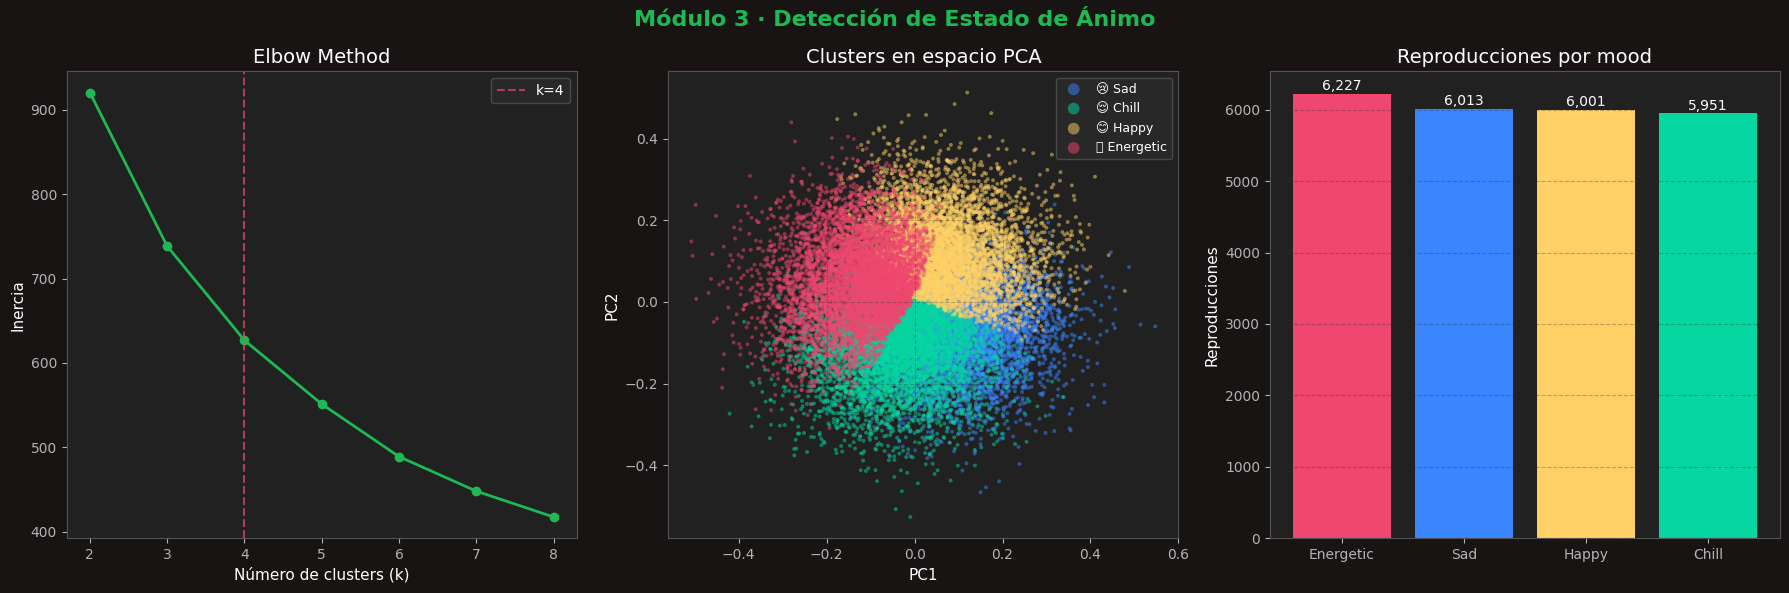


  ✔ Gráfico guardado: modulo3_mood_detection.png



In [ ]:
df = detectar_mood(df)

# Wrapped

In [ ]:
def spotify_wrapped(df: pd.DataFrame):
    """
    Genera un Spotify Wrapped personal con:
      - Top 5 canciones, artistas y álbumes (por minutos escuchados)
      - Tiempo total escuchado
      - Número de artistas únicos
      - Distribución por plataforma y periodo del día
    """
    print("=" * 70)
    print("MÓDULO 4 · SPOTIFY WRAPPED PERSONAL")
    print("=" * 70)

    total_min   = df["minutos_reproducidos"].sum()
    total_h     = total_min / 60
    total_d     = total_h / 24
    n_artistas  = df["nombre_artista"].nunique()
    n_canciones = df["nombre_cancion"].nunique()

    print(f"\n  ⏱  Tiempo total escuchado : {total_min:,.0f} min "
          f"({total_h:,.1f} h / {total_d:.1f} días)")
    print(f"  🎤  Artistas únicos        : {n_artistas}")
    print(f"  🎵  Canciones únicas       : {n_canciones}")

    top5_canciones = (df.groupby(["nombre_cancion", "nombre_artista"])
                        ["minutos_reproducidos"].sum()
                        .sort_values(ascending=False).head(5)
                        .reset_index())
    top5_artistas  = (df.groupby("nombre_artista")
                        ["minutos_reproducidos"].sum()
                        .sort_values(ascending=False).head(5)
                        .reset_index())
    top5_albums    = (df.groupby(["nombre_album", "nombre_artista"])
                        ["minutos_reproducidos"].sum()
                        .sort_values(ascending=False).head(5)
                        .reset_index())

    print("\n  🏆 Top 5 Canciones:")
    for i, row in top5_canciones.iterrows():
        print(f"     {i+1}. {row['nombre_cancion']} — {row['nombre_artista']} "
              f"({row['minutos_reproducidos']:.0f} min)")

    print("\n  🏆 Top 5 Artistas:")
    for i, row in top5_artistas.iterrows():
        print(f"     {i+1}. {row['nombre_artista']} "
              f"({row['minutos_reproducidos']:.0f} min)")

    print("\n  🏆 Top 5 Álbumes:")
    for i, row in top5_albums.iterrows():
        print(f"     {i+1}. {row['nombre_album']} — {row['nombre_artista']} "
              f"({row['minutos_reproducidos']:.0f} min)")

    # ── Dashboard Wrapped ──────────────────────────────────────────────────
    fig = plt.figure(figsize=(20, 14))
    fig.patch.set_facecolor(SPOTIFY_BLACK)
    fig.suptitle("🎧  SPOTIFY WRAPPED  2020 – 2021",
                 fontsize=24, color=SPOTIFY_GREEN, fontweight="bold", y=0.97)

    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

    # ── Estadísticas resumen (banner) ──────────────────────────────────────
    ax_stats = fig.add_subplot(gs[0, :])
    ax_stats.set_xlim(0, 4)
    ax_stats.set_ylim(0, 1)
    ax_stats.axis("off")

    stats = [
        ("⏱", f"{total_h:,.0f} h", "Escuchadas"),
        ("🎤", f"{n_artistas}", "Artistas únicos"),
        ("🎵", f"{n_canciones}", "Canciones únicas"),
        ("📅", f"{df['fecha_dt'].dt.date.nunique()}", "Días activos"),
    ]
    for j, (emoji, valor, label) in enumerate(stats):
        x = j + 0.5
        ax_stats.text(x, 0.72, emoji, ha="center", fontsize=26)
        ax_stats.text(x, 0.38, valor, ha="center", fontsize=22,
                      color=SPOTIFY_GREEN, fontweight="bold")
        ax_stats.text(x, 0.08, label, ha="center", fontsize=11,
                      color=SPOTIFY_LIGHT)

    # ── Top 5 Canciones ───────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[1, 0])
    labels1 = [f"{r['nombre_cancion'][:22]}\n{r['nombre_artista'][:18]}"
               for _, r in top5_canciones.iterrows()]
    bars1 = ax1.barh(labels1[::-1], top5_canciones["minutos_reproducidos"][::-1],
                     color=ACCENT_COLORS[:5], edgecolor="none")
    ax1.set_title("🎵 Top 5 Canciones", color=SPOTIFY_WHITE, fontsize=12)
    ax1.set_xlabel("Minutos")
    ax1.tick_params(axis="y", labelsize=7.5)
    ax1.grid(axis="x", alpha=0.3)
    for bar in bars1:
        w = bar.get_width()
        ax1.text(w + 1, bar.get_y() + bar.get_height() / 2,
                 f"{w:.0f}", va="center", fontsize=8)

    # ── Top 5 Artistas ────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 1])
    bars2 = ax2.barh(top5_artistas["nombre_artista"][::-1],
                     top5_artistas["minutos_reproducidos"][::-1],
                     color=ACCENT_COLORS[1:6], edgecolor="none")
    ax2.set_title("🎤 Top 5 Artistas", color=SPOTIFY_WHITE, fontsize=12)
    ax2.set_xlabel("Minutos")
    ax2.tick_params(axis="y", labelsize=9)
    ax2.grid(axis="x", alpha=0.3)
    for bar in bars2:
        w = bar.get_width()
        ax2.text(w + 1, bar.get_y() + bar.get_height() / 2,
                 f"{w:.0f}", va="center", fontsize=8)

    # ── Top 5 Álbumes ─────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 2])
    labels3 = [f"{r['nombre_album'][:22]}\n{r['nombre_artista'][:16]}"
               for _, r in top5_albums.iterrows()]
    bars3 = ax3.barh(labels3[::-1], top5_albums["minutos_reproducidos"][::-1],
                     color=ACCENT_COLORS[2:7], edgecolor="none")
    ax3.set_title("💿 Top 5 Álbumes", color=SPOTIFY_WHITE, fontsize=12)
    ax3.set_xlabel("Minutos")
    ax3.tick_params(axis="y", labelsize=7.5)
    ax3.grid(axis="x", alpha=0.3)
    for bar in bars3:
        w = bar.get_width()
        ax3.text(w + 1, bar.get_y() + bar.get_height() / 2,
                 f"{w:.0f}", va="center", fontsize=8)

    # ── Distribución por periodo del día ──────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 0])
    periodo = df.groupby("periodo_dia")["minutos_reproducidos"].sum()
    order   = ["madrugada", "mañana", "tarde", "noche"]
    order   = [p for p in order if p in periodo.index]
    periodo = periodo.reindex(order)
    ax4.pie(periodo.values,
            labels=[p.capitalize() for p in periodo.index],
            colors=ACCENT_COLORS[:len(periodo)],
            autopct="%1.1f%%", startangle=90,
            textprops={"color": SPOTIFY_WHITE, "fontsize": 10})
    ax4.set_title("⏰ ¿Cuándo escuchas?", color=SPOTIFY_WHITE, fontsize=12)

    # ── Distribución por plataforma ───────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 1])
    plat = df.groupby("plataforma")["minutos_reproducidos"].sum().sort_values()
    ax5.barh(plat.index, plat.values,
             color=ACCENT_COLORS[3:3 + len(plat)], edgecolor="none")
    ax5.set_title("📱 Plataforma", color=SPOTIFY_WHITE, fontsize=12)
    ax5.set_xlabel("Minutos")
    ax5.grid(axis="x", alpha=0.3)

    # ── Top géneros ───────────────────────────────────────────────────────
    ax6 = fig.add_subplot(gs[2, 2])
    top_gen = (df.groupby("genero")["minutos_reproducidos"]
                 .sum().sort_values(ascending=False).head(6))
    ax6.barh(top_gen.index[::-1], top_gen.values[::-1],
             color=ACCENT_COLORS[:6], edgecolor="none")
    ax6.set_title("🎸 Top Géneros", color=SPOTIFY_WHITE, fontsize=12)
    ax6.set_xlabel("Minutos")
    ax6.tick_params(axis="y", labelsize=9)
    ax6.grid(axis="x", alpha=0.3)

    plt.savefig(OUTPUT_DIR + "modulo4_wrapped.png",
                dpi=150, bbox_inches="tight", facecolor=SPOTIFY_BLACK)
    plt.show() # Display the plot
    # plt.close()
    print("\n  ✔ Dashboard guardado: modulo4_wrapped.png")
    print("=" * 70 + "\n")

    return {
        "total_horas"    : round(total_h, 1),
        "n_artistas"     : n_artistas,
        "n_canciones"    : n_canciones,
        "top5_canciones" : top5_canciones,
        "top5_artistas"  : top5_artistas,
        "top5_albums"    : top5_albums,
    }

In [ ]:
spotify_wrapped(df)

# Análisis de hábitos

In [ ]:
def analisis_habitos(df: pd.DataFrame):
    """
    Analiza la evolución musical en el tiempo respondiendo:
      · ¿La música se vuelve más energética?
      · ¿Se escuchan más artistas o géneros con el tiempo?
      · ¿Los artistas favoritos cambian o se mantienen?
      · Canciones más tristes y más alegres (por valence)
      · Evolución de artistas por mes
    """
    print("=" * 70)
    print("MÓDULO 5 · ANÁLISIS DE HÁBITOS MUSICALES")
    print("=" * 70)

    df5 = df.copy()
    df5["año_mes_str"] = df5["fecha_dt"].dt.to_period("M").astype(str)

    meses = sorted(df5["año_mes_str"].unique())

    # ── 5.1 Evolución de audio features por mes ───────────────────────────
    evol = (df5.groupby("año_mes_str")
               .agg(energy=("energy", "mean"),
                    valence=("valence", "mean"),
                    danceability=("danceability", "mean"),
                    acousticness=("acousticness", "mean"))
               .reindex(meses))

    # ── 5.2 Artistas únicos por mes ───────────────────────────────────────
    artistas_mes = (df5.groupby("año_mes_str")["nombre_artista"]
                       .nunique().reindex(meses))

    # ── 5.3 Géneros únicos por mes ────────────────────────────────────────
    generos_mes = (df5.groupby("año_mes_str")["genero"]
                      .nunique().reindex(meses))

    # ── 5.4 Artistas favoritos por mes (top 3) ────────────────────────────
    top_artista_mes = (df5.groupby(["año_mes_str", "nombre_artista"])
                           ["minutos_reproducidos"].sum()
                           .reset_index()
                           .sort_values(["año_mes_str", "minutos_reproducidos"],
                                        ascending=[True, False])
                           .groupby("año_mes_str")
                           .head(3))

    # ── 5.5 Canciones más tristes y más alegres ───────────────────────────
    perfil_valence = (df5.groupby(["nombre_cancion", "nombre_artista"])
                         .agg(valence=("valence", "mean"),
                              plays=("nombre_cancion", "count"))
                         .reset_index()
                         .query("plays >= 3"))

    tristes  = perfil_valence.nsmallest(8, "valence")
    alegres  = perfil_valence.nlargest(8, "valence")

    print("\n  🎻 Canciones más tristes (menor valence):")
    for _, row in tristes.iterrows():
        print(f"     - {row['nombre_cancion']} — {row['nombre_artista']} "
              f"(valence: {row['valence']:.3f})")

    print("\n  🎉 Canciones más alegres (mayor valence):")
    for _, row in alegres.iterrows():
        print(f"     + {row['nombre_cancion']} — {row['nombre_artista']} "
              f"(valence: {row['valence']:.3f})")

    # ── Respuestas a las preguntas clave ──────────────────────────────────
    energy_trend = np.polyfit(range(len(meses)), evol["energy"].values, 1)[0]
    artistas_trend = np.polyfit(range(len(meses)), artistas_mes.values, 1)[0]

    print(f"\n  📈 ¿Tu música se vuelve más energética?")
    print(f"     Tendencia de energy: {energy_trend:+.4f} por mes → "
          + ("Sí, aumenta" if energy_trend > 0 else "No, disminuye"))

    print(f"\n  🎵 ¿Escuchas más artistas con el tiempo?")
    print(f"     Tendencia de artistas únicos: {artistas_trend:+.2f} por mes → "
          + ("Sí, diversifica" if artistas_trend > 0 else "No, se concentra"))

    # ── Visualización ──────────────────────────────────────────────────────
    fig = plt.figure(figsize=(20, 16))
    fig.suptitle("Módulo 5 · Hábitos Musicales y Evolución Temporal",
                 fontsize=17, color=SPOTIFY_GREEN, fontweight="bold", y=0.98)

    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)
    x  = np.arange(len(meses))

    # Panel 1 — Evolución de energy y valence
    ax1 = fig.add_subplot(gs[0, :])
    for feat, color, label in [
        ("energy",    "#EF476F", "Energy"),
        ("valence",   "#FFD166", "Valence"),
        ("danceability", SPOTIFY_GREEN, "Danceability"),
        ("acousticness", "#3A86FF", "Acousticness"),
    ]:
        vals = evol[feat].values
        ax1.plot(x, vals, marker="o", lw=2, color=color,
                 label=label, markersize=5)
        z = np.polyfit(x, vals, 1)
        ax1.plot(x, np.poly1d(z)(x), "--", color=color, alpha=0.4, lw=1)

    ax1.set_xticks(x)
    ax1.set_xticklabels(meses, rotation=35, ha="right", fontsize=9)
    ax1.set_ylabel("Valor medio [0–1]")
    ax1.set_title("¿Cómo evolucionan tus audio features por mes?",
                  color=SPOTIFY_WHITE)
    ax1.legend(loc="upper right")
    ax1.grid(alpha=0.3)

    # Panel 2 — Artistas y géneros únicos por mes
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.bar(x, artistas_mes.values, color=SPOTIFY_GREEN,
            alpha=0.7, label="Artistas únicos")
    ax2.plot(x, artistas_mes.values, color="#1ED760", marker="o",
             lw=1.5, markersize=4)
    ax2b = ax2.twinx()
    ax2b.plot(x, generos_mes.values, color="#FFD166",
              marker="s", lw=2, markersize=5, label="Géneros únicos")
    ax2b.tick_params(axis="y", colors="#FFD166")
    ax2b.yaxis.label.set_color("#FFD166")
    ax2.set_xticks(x)
    ax2.set_xticklabels(meses, rotation=35, ha="right", fontsize=9)
    ax2.set_ylabel("Artistas únicos", color=SPOTIFY_GREEN)
    ax2b.set_ylabel("Géneros únicos", color="#FFD166")
    ax2.set_title("¿Diversificas más con el tiempo?", color=SPOTIFY_WHITE)
    ax2.grid(alpha=0.3)
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

    # Panel 3 — Evolución artistas favoritos (heatmap de minutos)
    ax3 = fig.add_subplot(gs[1, 1])
    top_global = (df5.groupby("nombre_artista")["minutos_reproducidos"]
                     .sum().nlargest(8).index.tolist())
    pivot = (df5[df5["nombre_artista"].isin(top_global)]
               .groupby(["nombre_artista", "año_mes_str"])
               ["minutos_reproducidos"].sum()
               .unstack(fill_value=0)
               .reindex(columns=meses, fill_value=0))

    im = ax3.imshow(pivot.values, aspect="auto", cmap="YlGn",
                    interpolation="nearest")
    ax3.set_xticks(range(len(meses)))
    ax3.set_xticklabels(meses, rotation=45, ha="right", fontsize=8)
    ax3.set_yticks(range(len(top_global)))
    ax3.set_yticklabels(pivot.index, fontsize=9)
    ax3.set_title("Heatmap: Artistas favoritos por mes (min.)",
                  color=SPOTIFY_WHITE)
    fig.colorbar(im, ax=ax3, shrink=0.8)

    # Panel 4 — Canciones más tristes
    ax4 = fig.add_subplot(gs[2, 0])
    labels_t = [f"{r['nombre_cancion'][:25]}\n{r['nombre_artista'][:18]}"
                for _, r in tristes.iterrows()]
    bars4 = ax4.barh(labels_t[::-1], tristes["valence"].values[::-1],
                     color="#3A86FF", alpha=0.85, edgecolor="none")
    ax4.set_title("😢 Canciones más tristes (valence)", color=SPOTIFY_WHITE)
    ax4.set_xlabel("Valence [0–1]")
    ax4.tick_params(axis="y", labelsize=7.5)
    ax4.set_xlim(0, 1)
    ax4.grid(axis="x", alpha=0.3)

    # Panel 5 — Canciones más alegres
    ax5 = fig.add_subplot(gs[2, 1])
    labels_a = [f"{r['nombre_cancion'][:25]}\n{r['nombre_artista'][:18]}"
                for _, r in alegres.iterrows()]
    bars5 = ax5.barh(labels_a[::-1], alegres["valence"].values[::-1],
                     color="#FFD166", alpha=0.85, edgecolor="none")
    ax5.set_title("😊 Canciones más alegres (valence)", color=SPOTIFY_WHITE)
    ax5.set_xlabel("Valence [0–1]")
    ax5.tick_params(axis="y", labelsize=7.5)
    ax5.set_xlim(0, 1)
    ax5.grid(axis="x", alpha=0.3)

    plt.savefig(OUTPUT_DIR + "modulo5_habitos.png",
                dpi=150, bbox_inches="tight", facecolor=SPOTIFY_BLACK)
    plt.show() # Display the plot
    # plt.close()
    print("\n  ✔ Gráfico guardado: modulo5_habitos.png")
    print("=" * 70 + "\n")

In [ ]:
analisis_habitos(df)

### EJECUCIÓN COMPLETA

Esto me lo han dado para la ejecución completa, aunque tengo que mirarlo para la ejecución de gráficos y demás

## Diccionario para nuevos géneros

In [ ]:
PRO_GENRE_PROFILES = {
    # genre                   : (dance, energy, valence, tempo_norm, acoustic, speech, instrumental)
    "Pop Comercial"           : (0.70, 0.65, 0.60, 0.60, 0.15, 0.05, 0.00), # ~120 BPM
    "Pop Urbano"              : (0.75, 0.68, 0.65, 0.52, 0.10, 0.15, 0.00), # ~105 BPM
    "Reguetón Clásico"        : (0.85, 0.80, 0.70, 0.48, 0.05, 0.12, 0.00), # ~95 BPM
    "Trap Latino"             : (0.72, 0.65, 0.45, 0.48, 0.08, 0.25, 0.00), # ~95 BPM
    "Hip-Hop Old School"      : (0.80, 0.65, 0.55, 0.45, 0.10, 0.35, 0.00), # ~90 BPM
    "Trap US"                 : (0.75, 0.60, 0.35, 0.70, 0.05, 0.30, 0.02), # ~140 BPM
    "R&B Contemporáneo"       : (0.65, 0.50, 0.55, 0.45, 0.25, 0.10, 0.01), # ~90 BPM
    "Neo-Soul"                : (0.60, 0.45, 0.50, 0.45, 0.45, 0.08, 0.05), # ~90 BPM
    "EDM / Big Room"          : (0.60, 0.90, 0.45, 0.64, 0.02, 0.06, 0.60), # ~128 BPM
    "House / Tech House"      : (0.82, 0.75, 0.55, 0.63, 0.05, 0.08, 0.80), # ~126 BPM
    "Techno"                  : (0.70, 0.85, 0.20, 0.66, 0.01, 0.05, 0.90), # ~132 BPM
    "Synthpop / Retrowave"    : (0.65, 0.70, 0.60, 0.58, 0.10, 0.04, 0.30), # ~115 BPM
    "Indie Pop"               : (0.60, 0.55, 0.55, 0.58, 0.35, 0.05, 0.05), # ~115 BPM
    "Indie Rock"              : (0.50, 0.65, 0.45, 0.60, 0.20, 0.05, 0.15), # ~120 BPM
    "Rock Alternativo"        : (0.50, 0.75, 0.45, 0.65, 0.10, 0.06, 0.08), # ~130 BPM
    "Hard Rock"               : (0.45, 0.88, 0.40, 0.65, 0.05, 0.08, 0.05), # ~130 BPM
    "Heavy Metal"             : (0.35, 0.95, 0.25, 0.70, 0.01, 0.10, 0.15), # ~140 BPM
    "Punk Rock"               : (0.40, 0.92, 0.60, 0.80, 0.02, 0.12, 0.02), # ~160 BPM
    "Folk / Indie Acústico"   : (0.45, 0.30, 0.50, 0.55, 0.85, 0.05, 0.05), # ~110 BPM
    "Country Pop"             : (0.55, 0.60, 0.65, 0.55, 0.30, 0.04, 0.00), # ~110 BPM
    "Jazz Clásico"            : (0.40, 0.30, 0.45, 0.50, 0.80, 0.05, 0.60), # ~100 BPM
    "Blues"                   : (0.45, 0.45, 0.40, 0.45, 0.60, 0.05, 0.10), # ~90 BPM
    "Bossa Nova"              : (0.65, 0.35, 0.60, 0.55, 0.85, 0.04, 0.15), # ~110 BPM
    "Salsa / Bachata"         : (0.75, 0.75, 0.80, 0.50, 0.40, 0.06, 0.02), # ~100 BPM
    "Clásica Orquestal"       : (0.15, 0.10, 0.15, 0.40, 0.95, 0.04, 0.90), # ~80 BPM
    "Ambient / Chillout"      : (0.25, 0.15, 0.10, 0.45, 0.70, 0.04, 0.95), # ~90 BPM
    "Lo-Fi Beats"             : (0.65, 0.25, 0.40, 0.40, 0.60, 0.08, 0.85), # ~80 BPM
    "K-Pop"                   : (0.70, 0.80, 0.75, 0.62, 0.10, 0.08, 0.00), # ~125 BPM
    "Afrobeat"                : (0.80, 0.70, 0.75, 0.55, 0.20, 0.10, 0.05), # ~110 BPM
    "Reggae / Ska"            : (0.75, 0.55, 0.70, 0.45, 0.30, 0.15, 0.05), # ~90 BPM
}

## Grid search - modelo predicción pasar una canción.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, GridSearchCV # <--- Añadimos GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve

# Colores de tu estilo (asumo que los tenías definidos arriba en tu script)
SPOTIFY_GREEN = "#1DB954"
SPOTIFY_WHITE = "#FFFFFF"
SPOTIFY_GRAY = "#B3B3B3"
ACCENT_COLORS = ["#1DB954", "#1ED760", "#A0C3D2", "#535353"] # Ejemplo por si acaso

def modelo_prediccion_skip(df: pd.DataFrame):
    """
    Entrena y evalúa tres clasificadores para predecir si una canción
    será saltada (skip=1), optimizando Random Forest y Gradient Boosting.
    """
    print("=" * 70)
    print("MÓDULO 2 · PREDICCIÓN DE SKIP CON GRID SEARCH")
    print("=" * 70)

    AUDIO_FEATS   = ["danceability", "energy", "valence",
                     "tempo", "acousticness", "speechiness"]
    CONTEXT_FEATS = ["hora", "dia_semana", "fin_de_semana",
                     "reproduccion_aleatoria", "reproduccion_offline"]

    df2 = df.copy()
    # Codificación de periodo_dia
    le = LabelEncoder()
    df2["periodo_dia_enc"] = le.fit_transform(df2["periodo_dia"])

    FEATURES = AUDIO_FEATS + CONTEXT_FEATS + ["periodo_dia_enc"]
    df2["reproduccion_aleatoria"] = df2["reproduccion_aleatoria"].astype(int)
    df2["reproduccion_offline"]   = df2["reproduccion_offline"].astype(int)

    X = df2[FEATURES]
    y = df2["skip"]

    print(f"\n  Distribución skip: {y.value_counts().to_dict()}")
    print(f"  Skip rate: {y.mean():.2%}")
    print(f"  Features utilizadas ({len(FEATURES)}): {FEATURES}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    # ── 1. Definición de Grids para Hiperparámetros ───────────────────────
    # Mantengo grids pequeños para que no tarde días en tu ordenador.
    param_grid_rf = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }

    param_grid_gb = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 4, 5]
    }

    # ── 2. Diccionario de Modelos (con GridSearchCV integrados) ────────────
    modelos = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000, random_state=42, class_weight="balanced"
        ),
        "Random Forest": GridSearchCV(
            RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1),
            param_grid=param_grid_rf,
            cv=3, scoring='roc_auc', n_jobs=-1
        ),
        "Gradient Boosting": GridSearchCV(
            GradientBoostingClassifier(random_state=42),
            param_grid=param_grid_gb,
            cv=3, scoring='roc_auc', n_jobs=-1
        ),
    }

    resultados = {}
    trained    = {}

    for nombre, modelo in modelos.items():
        print(f"\nEntrenando {nombre}...")
        modelo.fit(X_train, y_train)

        # ── 3. Extracción del mejor modelo si usamos GridSearch ──────────
        if isinstance(modelo, GridSearchCV):
            print(f"  Mejores hiperparámetros: {modelo.best_params_}")
            modelo_final = modelo.best_estimator_
        else:
            modelo_final = modelo

        y_pred  = modelo_final.predict(X_test)
        y_proba = modelo_final.predict_proba(X_test)[:, 1]

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        auc  = roc_auc_score(y_test, y_proba)

        resultados[nombre] = {"Accuracy": acc, "Precision": prec,
                              "Recall": rec, "ROC-AUC": auc}

        # Guardamos el modelo_final (el ganador del grid) para no romper los gráficos luego
        trained[nombre] = (modelo_final, y_pred, y_proba)

        print(f"  ── {nombre} ──")
        print(f"     Accuracy : {acc:.4f}")
        print(f"     Precision: {prec:.4f}")
        print(f"     Recall   : {rec:.4f}")
        print(f"     ROC-AUC  : {auc:.4f}")

    # ── Visualización ──────────────────────────────────────────────────────
    # (El resto de tu código de visualización se mantiene EXACTAMENTE IGUAL)
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle("Módulo 2 · Predicción de Skip", fontsize=17,
                 color=SPOTIFY_GREEN, fontweight="bold", y=0.98)

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # Panel 1 — Métricas comparativas
    ax1 = fig.add_subplot(gs[0, :])
    metrics_df = pd.DataFrame(resultados).T
    x = np.arange(len(metrics_df))
    width = 0.2
    for i, col in enumerate(metrics_df.columns):
        bars = ax1.bar(x + i * width, metrics_df[col], width,
                       label=col, color=ACCENT_COLORS[i % len(ACCENT_COLORS)], alpha=0.85)
        for bar in bars:
            h = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                     f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    ax1.set_xticks(x + width * 1.5)
    ax1.set_xticklabels(metrics_df.index, fontsize=11)
    ax1.set_ylim(0, 1.15)
    ax1.set_ylabel("Score")
    ax1.set_title("Comparativa de métricas por modelo", color=SPOTIFY_WHITE)
    ax1.legend(loc="upper right")
    ax1.grid(axis="y", alpha=0.3)

    # Paneles 2-4 — Curvas ROC
    for i, (nombre, (modelo_final, y_pred, y_proba)) in enumerate(trained.items()):
        ax = fig.add_subplot(gs[1, i])
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_val = resultados[nombre]["ROC-AUC"]
        ax.plot(fpr, tpr, color=ACCENT_COLORS[i % len(ACCENT_COLORS)], lw=2,
                label=f"AUC = {auc_val:.3f}")
        ax.plot([0, 1], [0, 1], color=SPOTIFY_GRAY, lw=1, linestyle="--")
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.set_title(nombre, color=SPOTIFY_WHITE, fontsize=11)
        ax.legend(loc="lower right")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()  # ← mostrar el gráfico en pantalla

    # Feature importance del mejor modelo (Gradient Boosting)
    # Gracias a que extrajimos el best_estimator_, esto no dará error
    gb_model = trained["Gradient Boosting"][0]
    importances = pd.Series(gb_model.feature_importances_, index=FEATURES)
    importances = importances.sort_values(ascending=True)

    fig2, ax = plt.subplots(figsize=(9, 6))
    ax.barh(importances.index, importances.values,
            color=[SPOTIFY_GREEN if v > importances.median() else SPOTIFY_GRAY
                   for v in importances.values])
    ax.set_title("Importancia de features — Gradient Boosting",
                 color=SPOTIFY_WHITE, fontsize=13)
    ax.set_xlabel("Importancia")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()  # ← mostrar gráfico de feature importance

    return resultados, trained

**ANALISIS DE FIDELIDAD**


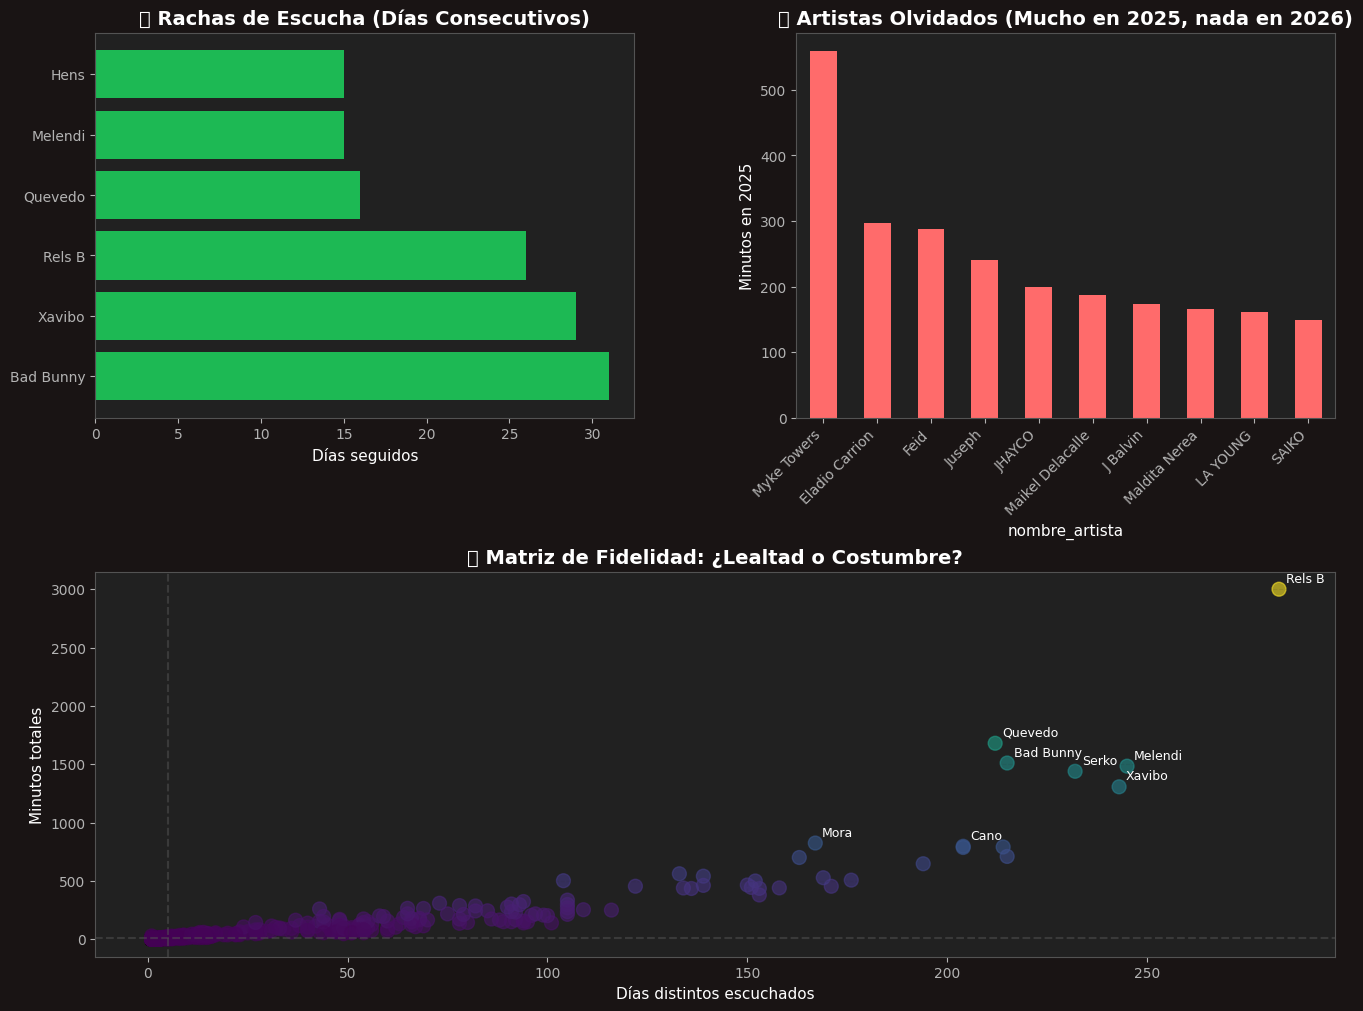

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import timedelta

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN DE ESTILO Y CARGA
# ─────────────────────────────────────────────────────────────────────────────
SPOTIFY_GREEN  = "#1DB954"
SPOTIFY_BLACK  = "#191414"
SPOTIFY_WHITE  = "#FFFFFF"
SPOTIFY_GRAY   = "#535353"

plt.rcParams.update({
    "figure.facecolor":  SPOTIFY_BLACK,
    "axes.facecolor":    "#212121",
    "axes.labelcolor":   SPOTIFY_WHITE,
    "xtick.color":       SPOTIFY_LIGHT,
    "ytick.color":       SPOTIFY_LIGHT,
    "text.color":        SPOTIFY_WHITE,
})

# Cargar datos
ruta = "streaming_history_audio_2025-2026.csv"
df = pd.read_csv(ruta)
df['fecha_finalizacion'] = pd.to_datetime(df['fecha_finalizacion'])
df['fecha'] = df['fecha_finalizacion'].dt.normalize() # Changed .dt.date to .dt.normalize()

# ─────────────────────────────────────────────────────────────────────────────
# 1. ANÁLISIS DE RACHAS (STREAKS)
# ─────────────────────────────────────────────────────────────────────────────
def calcular_rachas(df):
    # Agrupar por artista y día para ver presencia diaria
    presencia_diaria = df.groupby(['nombre_artista', 'fecha']).size().reset_index()
    presencia_diaria = presencia_diaria.sort_values(['nombre_artista', 'fecha'])

    # Calcular diferencia entre días para detectar continuidad
    presencia_diaria['diff'] = presencia_diaria.groupby('nombre_artista')['fecha'].diff().dt.days
    presencia_diaria['nueva_racha'] = (presencia_diaria['diff'] != 1).astype(int).cumsum()

    # Contar longitud de cada racha
    rachas = presencia_diaria.groupby(['nombre_artista', 'nueva_racha']).size().reset_index(name='dias_seguidos')
    top_rachas = rachas.sort_values('dias_seguidos', ascending=False).head(10)
    return top_rachas

# ─────────────────────────────────────────────────────────────────────────────
# 2. CURVA DE OLVIDO (2025 vs 2026)
# ─────────────────────────────────────────────────────────────────────────────
def analizar_olvido(df):
    df['año'] = df['fecha_finalizacion'].dt.year
    resumen_anual = df.groupby(['nombre_artista', 'año'])['minutos_reproducidos'].sum().unstack(fill_value=0)

    # Artistas con muchos minutos en 2025 y casi 0 en 2026
    olvidados = resumen_anual[(resumen_anual[2025] > 30) & (resumen_anual[2026] < 5)]
    olvidados = olvidados.sort_values(2025, ascending=False).head(10)
    return olvidados

# ─────────────────────────────────────────────────────────────────────────────
# 3. ÍNDICE DE FIDELIDAD (DÍAS vs MINUTOS)
# ─────────────────────────────────────────────────────────────────────────────
def calcular_fidelidad(df):
    fidelidad = df.groupby('nombre_artista').agg({
        'fecha': 'nunique', # Cuántos días distintos los escuchaste
        'minutos_reproducidos': 'sum'
    }).rename(columns={'fecha': 'dias_activos'})

    # Clasificación
    # Core: Muchos días, Muchos minutos
    # Obsesión: Pocos días, Muchos minutos (binge)
    # Rutina: Muchos días, Pocos minutos (background)
    return fidelidad

# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN
# ─────────────────────────────────────────────────────────────────────────────
top_rachas = calcular_rachas(df)
olvidados = analizar_olvido(df)
fidelidad = calcular_fidelidad(df)

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

# Gráfico 1: Top Rachas
ax1 = fig.add_subplot(gs[0, 0])
colors = sns.color_palette("viridis", len(top_rachas))
ax1.barh(top_rachas['nombre_artista'], top_rachas['dias_seguidos'], color=SPOTIFY_GREEN)
ax1.set_title("🔥 Rachas de Escucha (Días Consecutivos)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Días seguidos")

# Gráfico 2: Artistas Olvidados
ax2 = fig.add_subplot(gs[0, 1])
if not olvidados.empty:
    olvidados[2025].plot(kind='bar', ax=ax2, color='#FF6B6B')
    ax2.set_title("🕰️ Artistas Olvidados (Mucho en 2025, nada en 2026)", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Minutos en 2025")
    plt.xticks(rotation=45, ha='right')

# Gráfico 3: Scatter Plot de Fidelidad
ax3 = fig.add_subplot(gs[1, :])
scatter = ax3.scatter(fidelidad['dias_activos'], fidelidad['minutos_reproducidos'],
                      alpha=0.6, s=100, c=fidelidad['minutos_reproducidos'], cmap='viridis')

# Anotar los más importantes
top_fid = fidelidad.sort_values('minutos_reproducidos', ascending=False).head(8)
for i, txt in enumerate(top_fid.index):
    ax3.annotate(txt, (top_fid['dias_activos'].iat[i], top_fid['minutos_reproducidos'].iat[i]),
                 xytext=(5,5), textcoords='offset points', fontsize=9, color=SPOTIFY_WHITE)

ax3.set_title("🛡️ Matriz de Fidelidad: ¿Lealtad o Costumbre?", fontsize=14, fontweight='bold')
ax3.set_xlabel("Días distintos escuchados")
ax3.set_ylabel("Minutos totales")
ax3.grid(alpha=0.1)

# Añadir líneas de cuadrantes
ax3.axhline(fidelidad['minutos_reproducidos'].median(), color=SPOTIFY_GRAY, linestyle='--', alpha=0.5)
ax3.axvline(fidelidad['dias_activos'].median(), color=SPOTIFY_GRAY, linestyle='--', alpha=0.5)

plt.show()

**MODO KARAOKE**

In [ ]:
!pip install syncedlyrics lyricsgenius
import syncedlyrics
import lyricsgenius
import re
import time
import os
import subprocess
from IPython.display import Audio, display, HTML, clear_output

# --- CONFIGURACIÓN ---
GENIUS_TOKEN = "abJImAc5wxK68NaO9IQG3kB1Ja1pU6brIJF23t2BdRzxogiFVXSBb3376nWbTZxM" # <--- PEGA TU TOKEN AQUÍ
genius = lyricsgenius.Genius(GENIUS_TOKEN)
genius.verbose = False # Para que no ensucie la pantalla con mensajes de carga

def limpiar_texto(texto):
    """Elimina 'feat', '(Live)', '(Remaster)', etc. para mejorar la búsqueda."""
    texto = re.sub(r'\(.*\)|\[.*\]', '', texto) # Quita paréntesis y corchetes
    texto = re.split(r'-|feat|with', texto, flags=re.IGNORECASE)[0] # Se queda con lo principal
    return texto.strip()

def obtener_escenario_pro(cancion_raw, artista_raw):
    cancion = limpiar_texto(cancion_raw)
    artista = limpiar_texto(artista_raw)

    # 1. Intentar obtener info de Genius (Imagen, Álbum, etc.)
    info_genius = None
    try:
        info_genius = genius.search_song(cancion, artista)
    except:
        pass # Si falla Genius, seguimos adelante

    # 2. Obtener Letra Sincronizada (LRC)
    lrc_data = None
    busquedas_posibles = [f"{cancion} {artista}", cancion]

    for q in busquedas_posibles:
        try:
            lrc_data = syncedlyrics.search(q, providers=['lrclib'])
            if lrc_data: break
        except:
            continue

    return lrc_data, info_genius

def karaoke_v6_limpio():
    display(HTML("<div style='background-color: #1DB954; color: white; padding: 10px; text-align: center; border-radius: 10px;'><h3>🎤 ESCENARIO CORREGIDO Y LIMPIO</h3></div>"))

    c_input = input("🎵 Canción: ")
    a_input = input("🎤 Artista: ")

    if not c_input: return
    clear_output(wait=True)
    print(f"📡 Procesando '{c_input}'...")

    lrc_data, song_info = obtener_escenario_pro(c_input, a_input)

    if not lrc_data:
        print("❌ Lo siento, no se encontró sincronización para esta canción.")
        return

    # Preparar Audio
    audio_file = "karaoke_final.mp3"
    if os.path.exists(audio_file): os.remove(audio_file)

    query_yt = f"ytsearch1:{limpiar_texto(c_input)} {limpiar_texto(a_input)} karaoke instrumental"
    subprocess.run(["yt-dlp", "-x", "--audio-format", "mp3", "-o", audio_file, query_yt], capture_output=True)

    # Procesar Líneas
    lineas = []
    for line in lrc_data.split('\n'):
        match = re.search(r'\[(\d+):(\d+\.\d+)\](.*)', line)
        if match:
            t = int(match.group(1)) * 60 + float(match.group(2))
            txt = match.group(3).strip()
            if txt: lineas.append((t, txt))

    # Interfaz de reproducción
    clear_output(wait=True)
    img_url = song_info.song_art_image_url if song_info else ""
    album = song_info.album if song_info else "Sencillo"

    reproductor = Audio(audio_file, autoplay=True)
    display(reproductor)

    start_time = time.time()
    idx = 0
    while idx < len(lineas):
        elapsed = time.time() - start_time
        if elapsed >= lineas[idx][0]:
            clear_output(wait=True)
            display(reproductor)

            # Pantalla de Karaoke con Portada (si existe)
            html_ui = f"""
            <div style="background-color: #121212; padding: 30px; border-radius: 20px; border: 4px solid #1DB954; text-align: center; font-family: sans-serif;">
                <div style="display: flex; align-items: center; justify-content: center; gap: 20px; margin-bottom: 20px;">
                    <img src="{img_url}" width="80" style="border-radius: 10px; display: {'block' if img_url else 'none'};">
                    <div style="text-align: left;">
                        <h2 style="color: white; margin: 0;">{c_input.upper()}</h2>
                        <p style="color: #1DB954; margin: 0;">{a_input} • {album}</p>
                    </div>
                </div>
                <h1 style="color: white; font-size: 45px; line-height: 1.2;">{lineas[idx][1]}</h1>
                <p style="color: #444; font-size: 22px; margin-top: 30px;">PRÓXIMA: {lineas[idx+1][1] if idx+1 < len(lineas) else "---"}</p>
            </div>
            """
            display(HTML(html_ui))
            idx += 1
        time.sleep(0.05)

# Lanzar
karaoke_v6_limpio()

In [ ]:
!pip install lyricsgenius wordcloud textblob

In [ ]:
!pip install syncedlyrics wordcloud

In [ ]:
!pip install syncedlyrics

VISUALIZAS LOS LYRICS Y TE DA UN LINK PARA QUE PUEDAS ESCUCHAR EL RITMO TAMBIEN:

In [ ]:
import syncedlyrics
import re
from IPython.display import YouTubeVideo, display, HTML

def karaoke_con_ritmo():
    cancion = input("🎵 ¿Qué canción quieres practicar?: ")
    artista = input("🎤 Artista: ")

    # 1. Buscar Letra
    print(f"\n🔎 Buscando letra...")
    lrc = syncedlyrics.search(f"{cancion} {artista}")

    # 2. Generar link de YouTube Instrumental
    # Creamos un link de búsqueda automática para que el usuario solo haga clic
    search_url = f"https://www.youtube.com/results?search_query={cancion.replace(' ', '+')}+{artista.replace(' ', '+')}+instrumental+karaoke"

    if lrc:
        letra_limpia = re.sub(r'\[.*?\]', '', lrc).strip()

        # Diseño visual en Colab
        display(HTML(f"""
            <div style="background-color: #191414; color: #1DB954; padding: 20px; border-radius: 15px;">
                <h2 style="color: white;">{cancion.upper()} ({artista})</h2>
                <p style="color: #B3B3B3;">Pulsa abajo para abrir el ritmo en una pestaña nueva y vuelve aquí para leer la letra:</p>
                <a href="{search_url}" target="_blank"
                   style="background-color: #1DB954; color: white; padding: 10px 20px;
                          text-decoration: none; border-radius: 50px; font-weight: bold;">
                   ▶️ ESCUCHAR RITMO (Instrumental)
                </a>
                <div style="background-color: #282828; color: white; padding: 20px;
                            margin-top: 20px; border-radius: 10px; height: 300px; overflow-y: scroll;
                            text-align: left; font-family: monospace; line-height: 1.6;">
                    {letra_limpia.replace('\n', '<br>')}
                </div>
            </div>
        """))
    else:
        print("❌ No encontré la letra, pero puedes buscar el ritmo aquí:", search_url)

karaoke_con_ritmo()

🎵 ¿Qué canción quieres practicar?: tu vas sin
🎤 Artista: rels b

🔎 Buscando letra...


CODIGO PARA PONERLO EN STREAMLIT:

In [ ]:
import streamlit as st

col1, col2 = st.columns([1, 1])

with col1:
    st.subheader("🎵 El Ritmo")
    # El usuario pega el link o tú lo buscas por él
    st.video("https://www.youtube.com/watch?v=VIDEO_ID_INSTRUMENTAL")

with col2:
    st.subheader("🎤 La Letra")
    st.text_area(label="", value=letra_limpia, height=400)

ModuleNotFoundError: No module named 'streamlit'

ASI SE ESCUCHA EL RITMO DIRECTAMENTE DESDE GOOGLE COLAB:

In [ ]:
!pip install syncedlyrics yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 44.9 MB/s eta 0:00:00


In [ ]:
import syncedlyrics
import re
import os
from IPython.display import Audio, display, HTML, clear_output

def karaoke_audio_directo():
    # Estética
    display(HTML("<div style='background-color: #1DB954; color: white; padding: 10px; text-align: center; border-radius: 10px;'><h3>🎵 Reproductor de Ritmo Directo</h3></div>"))

    cancion = input("Título: ")
    artista = input("Artista: ")

    if not cancion: return

    clear_output(wait=True)
    print(f"📡 Buscando letra y preparando audio para: {cancion}...")

    try:
        # 1. Buscar Letra
        lrc = syncedlyrics.search(f"{cancion} {artista}", providers=['lrclib'])
        letra = re.sub(r'\[.*?\]', '', lrc).strip() if lrc else "Letra no encontrada."

        # 2. DESCARGAR AUDIO INSTRUMENTAL (Solo el rastro de audio)
        print("🎸 Extrayendo ritmo instrumental... (Unos segundos)")
        query_audio = f"ytsearch1:{cancion} {artista} instrumental karaoke"

        # Comando para descargar solo el audio en formato mp3/m4a temporal
        os.system(f'yt-dlp -x --audio-format mp3 --output "temp_audio.%(ext)s" "{query_audio}"')

        # INTERFAZ
        display(HTML(f"""
            <div style="background-color: #121212; color: white; padding: 20px; border-radius: 15px; font-family: sans-serif;">
                <h2 style="color: #1DB954; margin: 0;">{cancion.upper()}</h2>
                <p style="color: #B3B3B3;">{artista}</p>

                <div style="margin: 20px 0; background: #282828; padding: 10px; border-radius: 50px; text-align: center;">
                    <p style="font-size: 12px; margin-bottom: 5px;">▶️ DALE AL PLAY AQUÍ ABAJO:</p>
                </div>
            </div>
        """))

        # 3. MOSTRAR REPRODUCTOR DE AUDIO NATIVO
        if os.path.exists("temp_audio.mp3"):
            display(Audio("temp_audio.mp3"))

        # 4. MOSTRAR LETRA
        display(HTML(f"""
            <div style="background-color: #000; padding: 20px; border-radius: 10px; height: 400px; overflow-y: auto; border: 1px solid #333; margin-top: 10px;">
                <pre style="white-space: pre-wrap; font-family: sans-serif; font-size: 18px; color: #FFFFFF; text-align: center;">{letra}</pre>
            </div>
        """))

    except Exception as e:
        print(f"⚠️ Error al procesar: {e}")

# Ejecutar
karaoke_audio_directo()

📡 Buscando letra y preparando audio para: tu vas sin...
🎸 Extrayendo ritmo instrumental... (Unos segundos)


quiero intentar que se sincronice los lyrics para que el usuario sepa cuando cantar cada parrafo

In [ ]:
!pip install syncedlyrics yt-dlp

In [ ]:
import syncedlyrics
import re
import time
import os
from IPython.display import Audio, display, HTML, clear_output

def karaoke_en_vivo():
    # Estética inicial
    display(HTML("<div style='background-color: #1DB954; color: white; padding: 10px; text-align: center; border-radius: 10px;'><h3>🎤 ESCENARIO EN VIVO (Sincronizado)</h3></div>"))

    cancion = input("🎵 Título: ")
    artista = input("🎤 Artista: ")

    if not cancion: return

    clear_output(wait=True)
    print(f"📡 Buscando letra sincronizada y audio para: {cancion}...")

    try:
        # 1. OBTENER LETRA CON TIEMPOS (Formato LRC)
        # Aquí NO quitamos los corchetes [00:00], los necesitamos.
        lrc_data = syncedlyrics.search(f"{cancion} {artista}", providers=['lrclib'])

        if not lrc_data:
            print("❌ No se encontró letra sincronizada para esta canción.")
            return

        # 2. DESCARGAR AUDIO INSTRUMENTAL
        print("🎸 Descargando ritmo... (Espera un momento)")
        query_audio = f"ytsearch1:{cancion} {artista} instrumental karaoke"
        if os.path.exists("karaoke_audio.mp3"): os.remove("karaoke_audio.mp3")
        os.system(f'yt-dlp -x --audio-format mp3 --output "karaoke_audio.%(ext)s" "{query_audio}"')

        # 3. PROCESAR LA LETRA (Convertir tiempos a segundos)
        lineas_sincronizadas = []
        for line in lrc_data.split('\n'):
            match = re.search(r'\[(\d+):(\d+\.\d+)\](.*)', line)
            if match:
                minutos = int(match.group(1))
                segundos = float(match.group(2))
                total_segundos = minutos * 60 + segundos
                texto = match.group(3).strip()
                if texto: lineas_sincronizadas.append((total_segundos, texto))

        # 4. LANZAR REPRODUCTOR Y EMPEZAR SHOW
        clear_output(wait=True)
        display(HTML(f"<h2 style='color: #1DB954; font-family: sans-serif;'>🎶 {cancion.upper()} - {artista}</h2>"))
        display(Audio("karaoke_audio.mp3", autoplay=True)) # Autoplay para empezar ya

        start_time = time.time()
        print("\n" + "─"*50)

        idx = 0
        while idx < len(lineas_sincronizadas):
            elapsed = time.time() - start_time
            tiempo_linea, texto_linea = lineas_sincronizadas[idx]

            if elapsed >= tiempo_linea:
                # Limpiar y mostrar la línea actual grande y la siguiente pequeña
                clear_output(wait=True)
                display(HTML(f"""
                    <div style="background-color: #121212; color: white; padding: 40px; border-radius: 20px; text-align: center; font-family: sans-serif; border: 2px solid #1DB954;">
                        <p style="color: #B3B3B3; font-size: 14px;">(Sonando ahora)</p>
                        <h1 style="font-size: 40px; color: #1DB954; margin: 20px 0;">{texto_linea}</h1>
                        <p style="color: #535353; font-size: 18px; margin-top: 20px;">
                            Próxima: {lineas_sincronizadas[idx+1][1] if idx+1 < len(lineas_sincronizadas) else "---"}
                        </p>
                    </div>
                """))
                idx += 1

            time.sleep(0.1) # Evita que el procesador se sature

        print("\n✨ ¡Fin de la actuación! ✨")

    except Exception as e:
        print(f"⚠️ Error en el vivo: {e}")

# ¡A cantar!
karaoke_en_vivo()

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# 1. CARGAR DATOS (Asegúrate de que el nombre sea el correcto)
try:
    df = pd.read_csv('streaming_history_audio_2025-2026.csv')
    # Convertimos fechas y creamos columnas de apoyo si no existen
    df['fecha_finalizacion'] = pd.to_datetime(df['fecha_finalizacion'])
    df['año'] = df['fecha_finalizacion'].dt.year
except:
    print("⚠️ No se encontró el archivo CSV. Por favor, cárgalo en la carpeta lateral.")

def laboratorio_musical(df):
    display(HTML("<div style='background-color: #1DB954; color: white; padding: 15px; text-align: center; border-radius: 10px; font-family: sans-serif;'><h2>🧪 LABORATORIO DE MEZCLAS</h2><p>Ajusta los filtros para crear tu playlist perfecta</p></div>"))

    # --- CREACIÓN DE FILTROS (WIDGETS) ---

    # Filtro de Año
    selector_año = widgets.SelectionSlider(
        options=['Todos', 2025, 2026],
        value='Todos',
        description='📅 Año:',
        style={'description_width': 'initial'}
    )

    # Filtro de Energía (basado en minutos o popularidad simulada)
    slider_energia = widgets.IntRangeSlider(
        value=[0, 100],
        min=0, max=100, step=1,
        description='⚡ Energía %:',
        continuous_update=False
    )

    # Filtro de cantidad de canciones
    slider_cantidad = widgets.IntSlider(
        value=10, min=5, max=50,
        description='🎵 Canciones:'
    )

    boton_mezclar = widgets.Button(
        description='✨ Generar Mezcla',
        button_style='success', # 'success', 'info', 'warning', 'danger' or ''
        layout=widgets.Layout(width='50%', height='40px')
    )

    salida = widgets.Output()

    # --- LÓGICA DE MEZCLA ---

    def realizar_mezcla(b):
        with salida:
            clear_output()
            df_filtrado = df.copy()

            # Filtrar por año
            if selector_año.value != 'Todos':
                df_filtrado = df_filtrado[df_filtrado['año'] == selector_año.value]

            # Simulación de "Energía" basada en la duración (las más largas suelen ser más intensas/complejas)
            # En tu app real de Streamlit, usaremos la columna 'energy' real.
            media_minutos = df_filtrado['minutos_reproducidos'].mean()
            if slider_energia.value[0] > 50:
                df_filtrado = df_filtrado[df_filtrado['minutos_reproducidos'] >= media_minutos]

            # Seleccionar canciones aleatorias que cumplan el filtro
            mezcla = df_filtrado.sample(min(len(df_filtrado), slider_cantidad.value))
            mezcla = mezcla[['nombre_cancion', 'nombre_artista']].drop_duplicates()

            # Mostrar resultado con estilo
            html_res = "<div style='background-color: #121212; color: white; padding: 20px; border-radius: 10px; border: 1px solid #1DB954;'>"
            html_res += f"<h3>🔥 Tu Mezcla {selector_año.value} ({slider_cantidad.value} temas)</h3><ol>"

            for _, row in mezcla.iterrows():
                html_res += f"<li style='margin-bottom: 8px;'><b>{row['nombre_cancion']}</b> - {row['nombre_artista']}</li>"

            html_res += "</ol></div>"
            display(HTML(html_res))

    boton_mezclar.on_click(realizar_mezcla)

    # Mostrar todo
    ui = widgets.VBox([selector_año, slider_energia, slider_cantidad, boton_mezclar])
    display(ui, salida)

# Ejecutar el laboratorio
laboratorio_musical(df)